In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Define known data points from the prompt
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1])

In [2]:
# Create a cubic spline interpolation of the data using natural boundary conditions
cs = CubicSpline(x, y, bc_type='natural')

# Generate new x values for a smooth plot
x_interp = np.linspace(0, 5, 100)

# Calculate interpolated y values using the spline
y_interp_spline = cs(x_interp)

In [3]:
# 1. Fit a degree 3 (Cubic) polynomial
coeffs_poly3 = np.polyfit(x, y, 3)
y_interp_poly3 = np.polyval(coeffs_poly3, x_interp)

# 2. Fit a degree 5 polynomial (will pass through all 6 points)
coeffs_poly5 = np.polyfit(x, y, 5)
y_interp_poly5 = np.polyval(coeffs_poly5, x_interp)

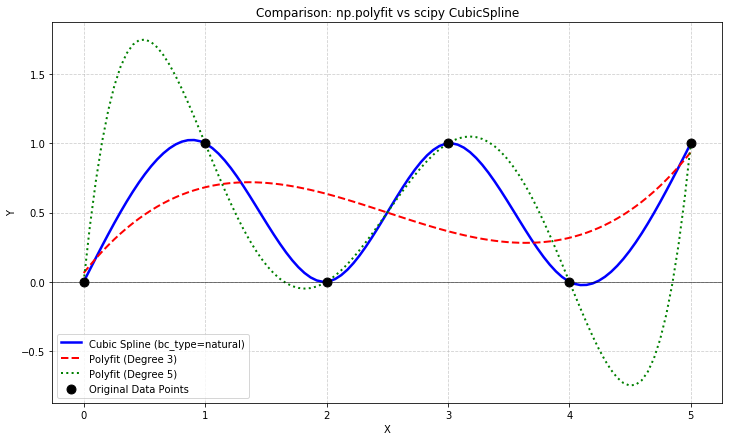

In [4]:
plt.figure(figsize=(12, 7))

# Plot the original data points
plt.scatter(x, y, color='black', s=80, label='Original Data Points', zorder=5)

# Plot the Cubic Spline
plt.plot(x_interp, y_interp_spline, color='blue', linewidth=2.5, label='Cubic Spline (bc_type=natural)')

# Plot the Polyfits
plt.plot(x_interp, y_interp_poly3, color='red', linestyle='--', linewidth=2, label='Polyfit (Degree 3)')
plt.plot(x_interp, y_interp_poly5, color='green', linestyle=':', linewidth=2, label='Polyfit (Degree 5)')

# Formatting the plot
plt.title('Comparison: np.polyfit vs scipy CubicSpline')
plt.xlabel('X')
plt.ylabel('Y')
plt.axhline(0, color='black', linewidth=0.5)
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()